# Mini-Project: Data Analysis for Marketing Strategy

This notebook analyzes the **US Superstore Dataset** and answers the required business questions using data preprocessing, aggregation, and visualizations.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)

# Load dataset
file_path = "US Superstore data.xls"   # Update path if needed
df = pd.read_excel(file_path)

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:

# Basic preprocessing
df.columns = df.columns.str.strip()

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.shape)
print(df.isna().sum())
df.info()


(9994, 21)
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segmen

## 1. Which states have the most sales?

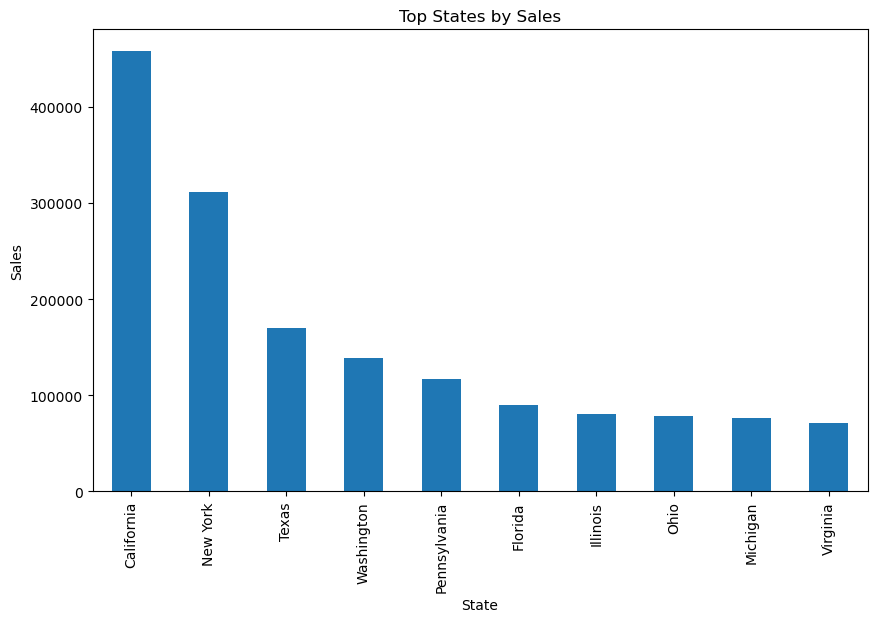

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

In [3]:

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

state_sales.head(10).plot(kind='bar')
plt.title('Top States by Sales')
plt.ylabel('Sales')
plt.show()

state_sales.head(10)


## 2. Difference between New York and California (Sales & Profit)

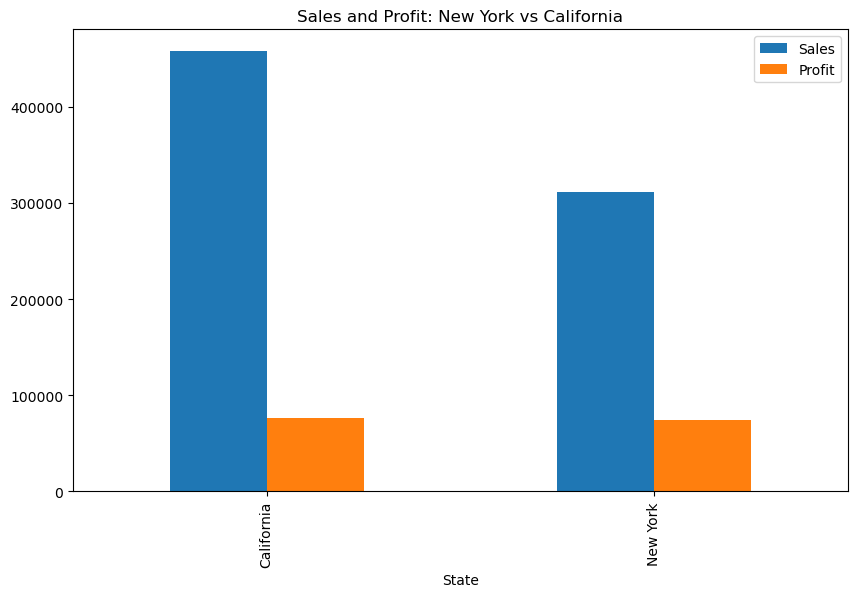

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486


In [4]:

comparison = df[df['State'].isin(['New York','California'])]     .groupby('State')[['Sales','Profit']].sum()

comparison.plot(kind='bar')
plt.title('Sales and Profit: New York vs California')
plt.show()

comparison


## 3. Outstanding customer in New York

In [5]:

ny_customer = (
    df[df['State']=='New York']
    .groupby('Customer Name')[['Sales','Profit']]
    .sum()
    .sort_values('Profit', ascending=False)
)

ny_customer.head(10)


,Sales,Profit
Customer Name,,
Tom Ashbrook,13723.498,4599.2073
Keith Dawkins,5854.194,2510.8903
Karen Daniels,6241.282,2283.0463
Nathan Mautz,4821.292,2247.1904
Tom Boeckenhauer,6999.960,2239.9872
Steven Roelle,3904.680,1863.9614
Pete Kriz,4816.690,1695.3209
Darrin Martin,4283.792,1599.6806
Todd Sumrall,6492.314,1574.9714


## 4. Profitability by State

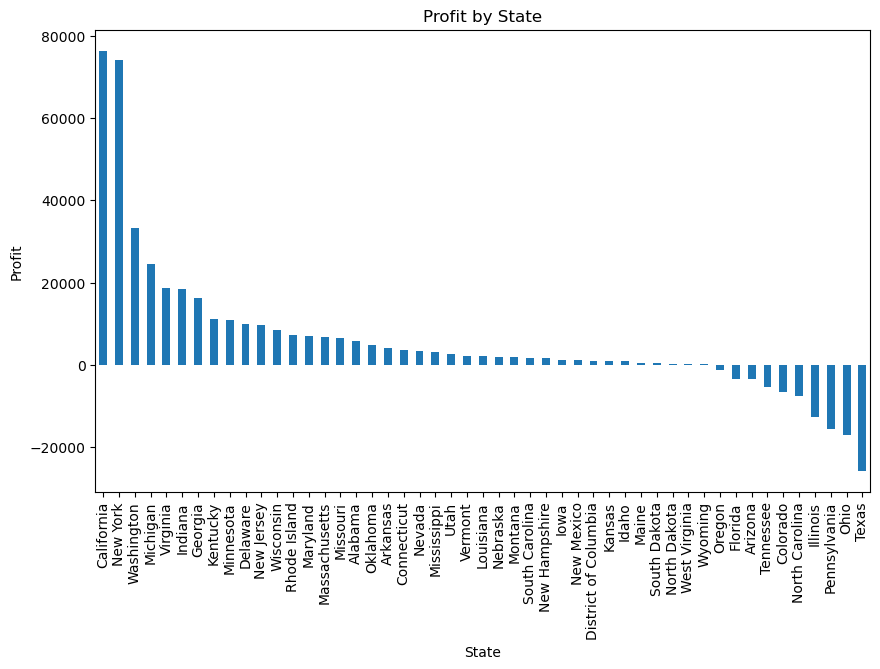

State
California       76381.3871
New York         74038.5486
Washington       33402.6517
Michigan         24463.1876
Virginia         18597.9504
Indiana          18382.9363
Georgia          16250.0433
Kentucky         11199.6966
Minnesota        10823.1874
Delaware          9977.3748
New Jersey        9772.9138
Wisconsin         8401.8004
Rhode Island      7285.6293
Maryland          7031.1788
Massachusetts     6785.5016
Missouri          6436.2105
Alabama           5786.8253
Oklahoma          4853.9560
Arkansas          4008.6871
Connecticut       3511.4918
Name: Profit, dtype: float64

In [6]:

state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

state_profit.plot(kind='bar')
plt.title('Profit by State')
plt.ylabel('Profit')
plt.show()

state_profit.head(20)


## 5. Pareto Principle on Customers and Profit

Top 20% customers contribute 81.66% of total profit


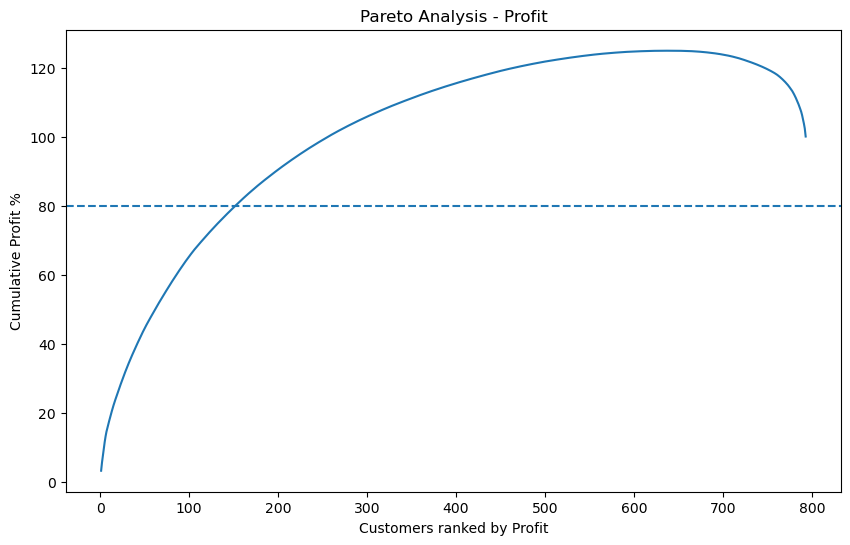

In [7]:

customer_profit = (
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
)

cum_profit_pct = customer_profit.cumsum() / customer_profit.sum() * 100

pareto_df = pd.DataFrame({
    'Profit': customer_profit,
    'Cumulative %': cum_profit_pct
})

top20_pct_customers = int(np.ceil(len(customer_profit)*0.2))

profit_share = (
    customer_profit.head(top20_pct_customers).sum()
    / customer_profit.sum() * 100
)

print(f"Top 20% customers contribute {profit_share:.2f}% of total profit")

plt.plot(range(1,len(cum_profit_pct)+1), cum_profit_pct.values)
plt.axhline(80, linestyle='--')
plt.title('Pareto Analysis - Profit')
plt.ylabel('Cumulative Profit %')
plt.xlabel('Customers ranked by Profit')
plt.show()


## 6. Top 20 Cities by Sales and Profit

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64

City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64

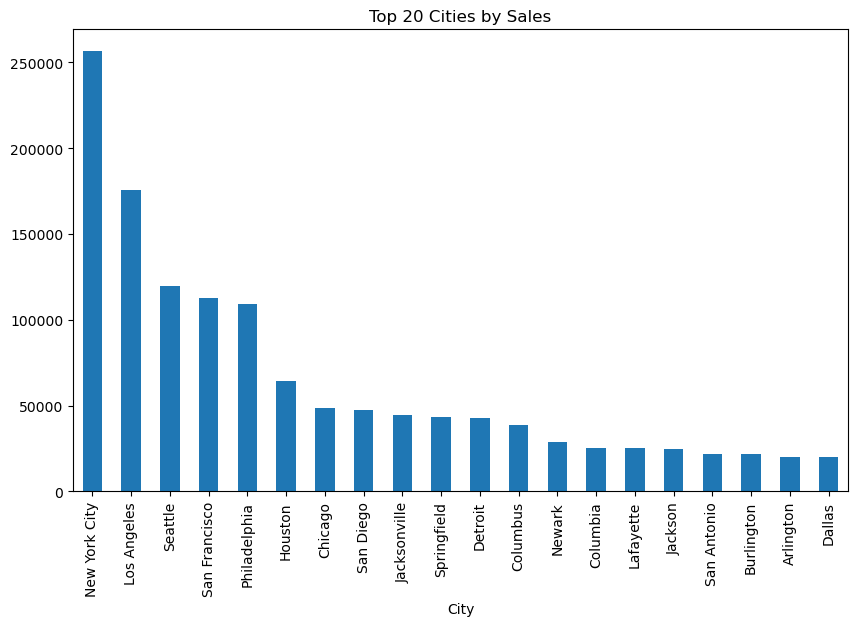

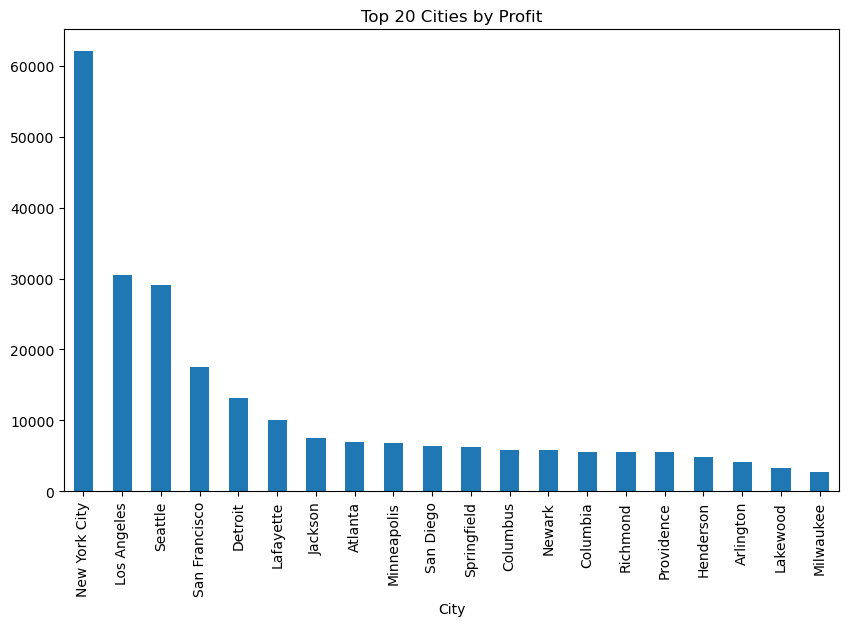

In [8]:

top20_sales_city = (
    df.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_profit_city = (
    df.groupby('City')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

display(top20_sales_city)
display(top20_profit_city)

top20_sales_city.plot(kind='bar')
plt.title('Top 20 Cities by Sales')
plt.show()

top20_profit_city.plot(kind='bar')
plt.title('Top 20 Cities by Profit')
plt.show()


## 7. Top 20 Customers by Sales

In [9]:

top20_customers_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_customers_sales


Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64

## 8. Cumulative Sales Curve & Pareto Analysis

Top 20% customers contribute 48.15% of total sales


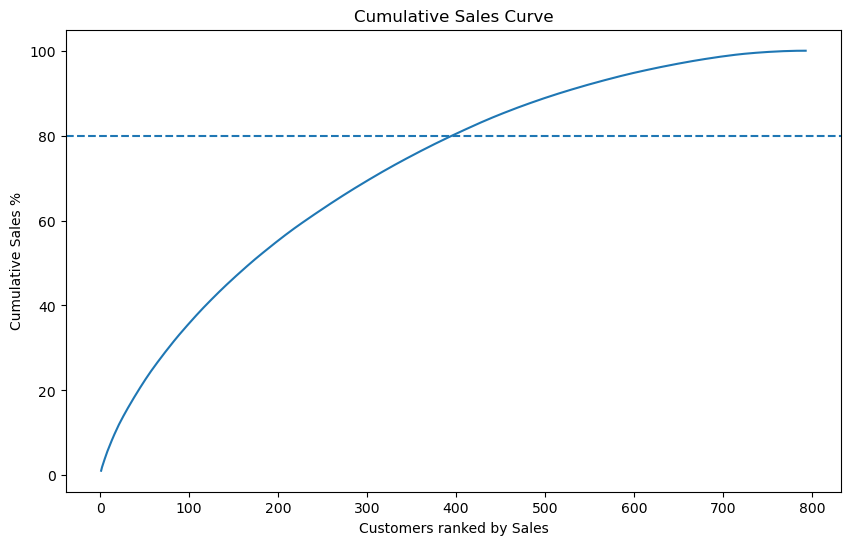

In [10]:

customer_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

cum_sales_pct = customer_sales.cumsum()/customer_sales.sum()*100

top20_pct_customers = int(np.ceil(len(customer_sales)*0.2))

sales_share = (
    customer_sales.head(top20_pct_customers).sum()
    / customer_sales.sum() * 100
)

print(f"Top 20% customers contribute {sales_share:.2f}% of total sales")

plt.plot(range(1,len(cum_sales_pct)+1), cum_sales_pct.values)
plt.axhline(80, linestyle='--')
plt.title('Cumulative Sales Curve')
plt.ylabel('Cumulative Sales %')
plt.xlabel('Customers ranked by Sales')
plt.show()


## 9. Marketing Recommendations

After executing the notebook:

- Prioritize states with the highest sales and profit.
- Focus marketing investments on cities appearing in both Top 20 Sales and Top 20 Profit rankings.
- Retain and reward high-value customers identified through Pareto analysis.
- Investigate states or cities with strong sales but weak profitability.
- Develop targeted campaigns for the most profitable customer segments.
